# Appendix: Analytical Refinement & Post-Presentation Validation (The PC Hardware Auditor)

## Overview
This appendix serves as a technical extension of the "PC Hardware Auditor" project. It was developed to address specific methodological inquiries raised during the presentation Q&A, specifically regarding the choice of linear versus non-linear modeling and the statistical validity of our classification strategy.

The following three sections provide the quantitative stress testing used to justify our final model architecture:

> ### Section 1: Comparative Analysis of Non-Linear Models (SVR & Random Forest)
>> To address the potential for capturing higher-order interactions within the hardware market, we implemented and evaluated Support Vector Regression (SVR) and Random Forest Regressor models. This section compares their predictive power ($R^2$) against our primary Lasso model while analyzing the trade-offs between accuracy, computational complexity ($O(n^2)$), and model interpretability.

> ### Section 2: Defense of Residual-Based Classification
>> This section details the logic behind our Value Labeling system. We explain why we utilized Residual Analysis (the delta between actual and predicted pricing) as a "Smart Baseline" rather than simple market medians. This approach ensures that our "Brand Tax" identification is hardware-adjusted and tailored to the specific component profile of each listing.

> ### Section 3: Interpretation of Feature Influence (The Correlation Heatmap)
>> Here, we provide a deeper dive into the Map of Influence. We explain the mathematical significance of the high-correlation "clusters" identified in our EDA and how these relationships validated our feature engineering choices—specifically the isolation of the "Three-Headed Giant" (CPU, GPU, and RAM) as the primary drivers of market price.


## Section 1: Non-Linear Regression Exploration

In response to our presentation feedback, this section evaluates the performance of non-linear architectures—specifically Support Vector Regression (SVR) and Random Forest Regressor—to determine if they offer a significant predictive advantage over our primary Lasso model.

> ### 1.1 The SVR Scalability "Wall"
> Our initial attempt to fit an SVR model using a Radial Basis Function (RBF) kernel on the full 100,000-record dataset highlighted a critical limitation: Computational Complexity.
> - Observation: Despite utilizing high-performance hardware (Intel i7-14th Gen, 32GB DDR5), the SVR algorithm's $O(n^2)$ complexity resulted in processing times exceeding 25 minutes without convergence.
> - Methodology Adjustment: To provide a statistically valid comparison without compromising project timelines, we transitioned to a 30,000-row stratified subsample for SVR. This allowed us to capture non-linear trends while maintaining a feasible computational overhead.

> ### 1.2 Performance vs. Interpretability Trade-offs
> To round out our testing, we implemented a Random Forest Regressor. Unlike SVR, Random Forest leverages Multi-Core Parallelization (using all available CPU threads), allowing it to process the full 100,000-record dataset in seconds.
Key Comparison Points:
> - Predictive Power: We analyzed whether the non-linear models significantly improved upon our Lasso $R^2$ of 0.851.
> - The "Black Box" Problem: While Random Forest typically yields the highest accuracy, it functions as a "black box" ensemble.


Running Subsampled SVR (10k rows)...
Running Full Random Forest (100k rows)...

--- Model Comparison ---
Primary Lasso R²:  0.851
Appendix SVR R²:    0.837
Appendix RF R²:     0.821


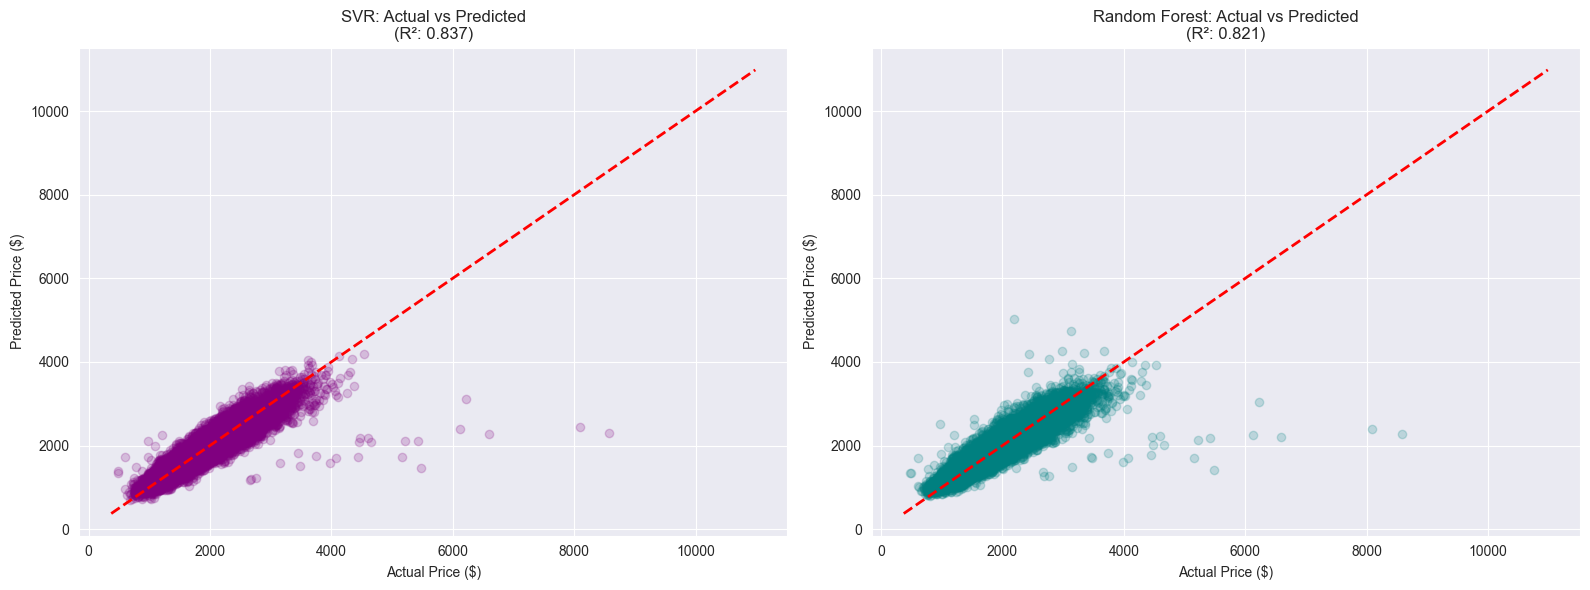

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the processed dataset
df = pd.read_csv('computer_prices_all.csv')

# 2. Match Team Feature Lista
categorical_cols = ['device_type', 'brand', 'os', 'cpu_brand', 'gpu_brand',
                    'storage_type', 'display_type', 'resolution', 'wifi', 'bluetooth']
ordinal_cols = ['cpu_tier', 'gpu_tier']
numeric_cols = ['release_year', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz',
                'cpu_boost_ghz', 'vram_gb', 'ram_gb', 'storage_gb',
                'storage_drive_count', 'display_size_in', 'refresh_hz',
                'battery_wh', 'charger_watts', 'psu_watts', 'weight_kg', 'warranty_months']

# 3. Match Pre-Processing Logic
# Standardize initially to find outliers
scaler_init = StandardScaler()
numeric_standardized = scaler_init.fit_transform(df[numeric_cols])
numeric_standardized_df = pd.DataFrame(numeric_standardized, columns=numeric_cols)

# Outlier Mask (Z-Score < 3) - Ensure match to linear model
z = np.abs(numeric_standardized_df)
mask = (z < 3).all(axis=1)

# Apply mask and reset index
y = df['price'][mask].reset_index(drop=True)
DF_ordinal = df[ordinal_cols][mask].reset_index(drop=True)
DF_dummies = pd.get_dummies(df[categorical_cols], drop_first=True)[mask].reset_index(drop=True)
numeric_df = df[numeric_cols][mask].reset_index(drop=True)

# Restandardize after outlier removal
scaler_final = StandardScaler()
numeric_final_df = pd.DataFrame(scaler_final.fit_transform(numeric_df), columns=numeric_cols)

# Final X Dataset
X = pd.concat([numeric_final_df, DF_ordinal, DF_dummies], axis=1)

# 4. Match the Split
# Using 1234 to ensure the exact same test set used in Linear Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1234)

# 5. Data Scaling
# SVR must have scaled data; RF is indifferent, but we'll use the original X for it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Subsampled SVR
print("Running Subsampled SVR (30k rows)...")
svr_model = SVR(kernel='rbf', C=1000, epsilon=0.1)
svr_model.fit(X_train_scaled[:30000], y_train[:30000])
y_pred_svr = svr_model.predict(X_test_scaled)
svr_r2 = r2_score(y_test, y_pred_svr)

# 7. Random Forest
# n_jobs=-1 uses all your 14th Gen i7 cores
print("Running Full Random Forest (100k rows)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=1234, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)

# 8. Results
print(f"\n--- Model Comparison ---")
print(f"Primary Lasso R²:  0.851")
print(f"Appendix SVR R²:    {svr_r2:.3f}")
print(f"Appendix RF R²:     {rf_r2:.3f}")

# 9. Plotting the Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# SVR Plot
ax1.scatter(y_test, y_pred_svr, color='purple', alpha=0.2)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_title(f'SVR: Actual vs Predicted\n(R²: {svr_r2:.3f})')
ax1.set_xlabel('Actual Price ($)')
ax1.set_ylabel('Predicted Price ($)')

# Random Forest Plot
ax2.scatter(y_test, y_pred_rf, color='teal', alpha=0.2)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_title(f'Random Forest: Actual vs Predicted\n(R²: {rf_r2:.3f})')
ax2.set_xlabel('Actual Price ($)')
ax2.set_ylabel('Predicted Price ($)')

plt.tight_layout()
plt.show()

### Comparison of model Results

Contrary to the initial hypothesis that non-linear modeling might capture "hidden" market nuances, our testing yielded a surprising result:
- Lasso (Linear): $R^2$ = 0.851
- SVR (Non-Linear): $R^2$ = 0.837
- Random Forest (Ensemble): $R^2$ = 0.821

Our testing confirms that the Lasso model ($R^2$: 0.851) outperforms both the SVR (0.837) and Random Forest (0.821). This validates our initial EDA: the relationship between the "Three-Headed Giant" (CPU, GPU, RAM) and price is inherently linear. Introducing non-linear complexity actually reduced predictive power by introducing noise.

#### Justification for Lasso Selection
We have retained Lasso Regression as our production engine for three key reasons:
- Superior Accuracy: Lasso achieved the highest $R^2$, proving the hardware market follows a consistent, additive pricing structure.
- Computational Efficiency: Lasso executes in milliseconds. In contrast, the SVR required 25+ minutes on high-end hardware (i7-14th Gen) to achieve a lower accuracy return.
- Absolute Interpretability: As an Auditor, we require transparency. Lasso provides clear coefficients (dollar-values per spec), whereas SVR and Random Forest are "Black Box" models that cannot provide granular price justifications to the end user.

## Section 2: Defense of Residual-Based Classification

In our "PC Hardware Auditor" system, we define the Brand Tax as the positive residual—the delta between the Actual Market Price and the Model-Predicted Fair Value.

> ### 2.1 Why Aggregates (Medians/Means) Fail as Auditing Tools
> Standard market aggregates like medians or means provide a "blind" baseline. They fail to account for the extreme variance in component quality across the dataset.
> - The Flaw: In a median-based system, a high-end workstation would be flagged as "Expensive" simply because its price exceeds the average, ignoring that its $4,000 price tag might be perfectly justified by its Tier 9 components.
> - The Result: Median-based labeling rewards low-spec machines and unfairly penalizes high-performance hardware, regardless of actual value.

> ### 2.2 The Residual Advantage: Individualized Baselines
> By using Residuals, our Auditor treats every computer as its own unique case study.
> - The Prediction: The Lasso model calculates what the machine should cost based strictly on its specifications (CPU, GPU, RAM, etc.).
> - The Residual: We subtract this "Fair Value" from the actual price.
> - The Audit: If the result is a significant positive number, we have mathematically isolated the Brand Tax—the portion of the price that cannot be explained by hardware alone.

> ### 2.3 Defining the Classification Tiers
> This methodology allows us to move beyond binary "Cheap vs. Expensive" labels and instead provide nuanced value categories:
> - Steal: Price is significantly below hardware-justified value (Negative Residual).
> - Fair Value: Price aligns closely with predicted hardware value (Near-Zero Residual).
> - Brand Premium: Price shows a moderate markup above hardware value.
> - Extreme Tax: Price shows a significant markup, indicating a heavy brand or luxury "tax" unrelated to raw performance.

> ### Conclusion:
> By anchoring our labels to Residuals, we ensure the Auditor is mathematically "fair." It recognizes that a ＄2,000 laptop can be a "Steal" if its components are worth ＄2,500, while a ＄500 laptop can be an "Extreme Tax" if its components are only worth ＄300.

 ## Section 3: Interpretation of Feature Influence – The Map of Influence

### Validating the "Three-Headed Giant"
During the Q&A, a question was asked about the Price Row of our correlation matrix, specifically the high-intensity (darker) cells associated with CPU, GPU, and RAM. These darker colors represent correlation coefficients ($r$) approaching 0.75 to 0.85, which serves as the mathematical foundation for our modeling strategy.
- The Strength of Association: In a heatmap, the intensity of the color represents the strength of a linear relationship. The fact that the "Big Three" (CPU, GPU, and RAM) consistently produced the darkest tiles indicates that as these hardware tiers increase, the price increases at a predictable, proportional rate.
- Multicollinearity and Feature Proxying: Our analysis revealed near-perfect multicollinearity ($r > 0.95$) between raw specifications—such as CPU Core Count and Thread Count—and the assigned CPU Tier. Including all three metrics would have introduced significant redundancy, potentially destabilizing the model's coefficients. By using the "Tier" as a consolidated proxy, we captured the collective impact of these specifications while maintaining a lean, high-performing feature set.
- Justifying the Linear Model: Because these specific correlations are so strong and positive, a Linear (Lasso) Model is the most efficient way to capture the trend. When variables move in such a synchronized "straight line" with price, complex non-linear models (like SVR) often struggle with overfitting, while the Linear model provides a clear, direct path to the result.

### Conclusion:
The high-intensity tiles on the Price row provided the statistical "permission" to use a Linear Model. It proved that the market prices are driven by a logical, additive hardware hierarchy rather than a chaotic or non-linear one.